In [2]:
import os
import sys
import torch
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.10.0+cu128
CUDA available: True


In [3]:
import torch
print("Device:", torch.cuda.get_device_name(0))
print("Capability:", torch.cuda.get_device_capability(0))
print("Memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

Device: Tesla T4
Capability: (7, 5)
Memory (GB): 15.64


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
ls drive/MyDrive/Erdos-dl-hullseek/data-biofouling/

images/  metadata.csv


In [6]:
# ---- EDIT THESE PATHS ----
IMAGES_ROOT = r"/content/drive/MyDrive/Erdos-dl-hullseek/data-biofouling/images/"
METADATA_PATH = r"/content/drive/MyDrive/Erdos-dl-hullseek/data-biofouling/metadata.csv"   # or .csv

# Labels: SLoF 0,1,2
LABEL_MAP = {0: "nil", 1: "medium", 2: "heavy"}

# Training config
IMG_SIZE = 224
BATCH_TRAIN = 32
BATCH_VAL = 64
SEED = 42

In [7]:
def read_metadata(path: str) -> pd.DataFrame:
    if path.lower().endswith((".tsv", ".txt")):
        df = pd.read_csv(path, sep="\t")
    else:
        df = pd.read_csv(path)

    df.columns = [c.strip() for c in df.columns]
    df["split"] = df["split"].astype(str).str.lower().str.strip()
    df = df[df["SLoF"].isin([0, 1, 2])].copy()
    return df

df = read_metadata(METADATA_PATH)
df.head()

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split
0,000001-GNZuCtwed3.jpg,commercial-1,8,hull,0,3,training
1,000002-CAgNlUizNm.jpg,commercial-1,8,hull,0,3,training
2,000003-vDe7GN0NrL.jpg,commercial-1,8,hull,0,2,training
3,000004-TbUBpfn6iP.jpg,commercial-1,8,hull,0,2,training
4,000005-oemYWm1Tjg.jpg,commercial-1,8,hull,0,3,training


In [8]:
train_df = df[df["split"].isin(["training", "train"])].copy()
val_df   = df[df["split"].isin(["validation", "val"])].copy()

print("Train size:", len(train_df))
print("Val size:", len(val_df))

print("\nTrain class counts:")
print(train_df["SLoF"].value_counts().sort_index().rename(index=LABEL_MAP))

print("\nVal class counts:")
print(val_df["SLoF"].value_counts().sort_index().rename(index=LABEL_MAP))

# quick missing-file check
sample = pd.concat([train_df.head(200), val_df.head(200)], axis=0)
missing = []
for fname in sample["image.name"]:
    if not os.path.exists(os.path.join(IMAGES_ROOT, fname)):
        missing.append(fname)

print("\nMissing files (from sample):", len(missing))
if missing:
    print("Example missing:", missing[0])

Train size: 9422
Val size: 841

Train class counts:
SLoF
nil       7328
medium    1503
heavy      591
Name: count, dtype: int64

Val class counts:
SLoF
nil       494
medium    193
heavy     154
Name: count, dtype: int64

Missing files (from sample): 0


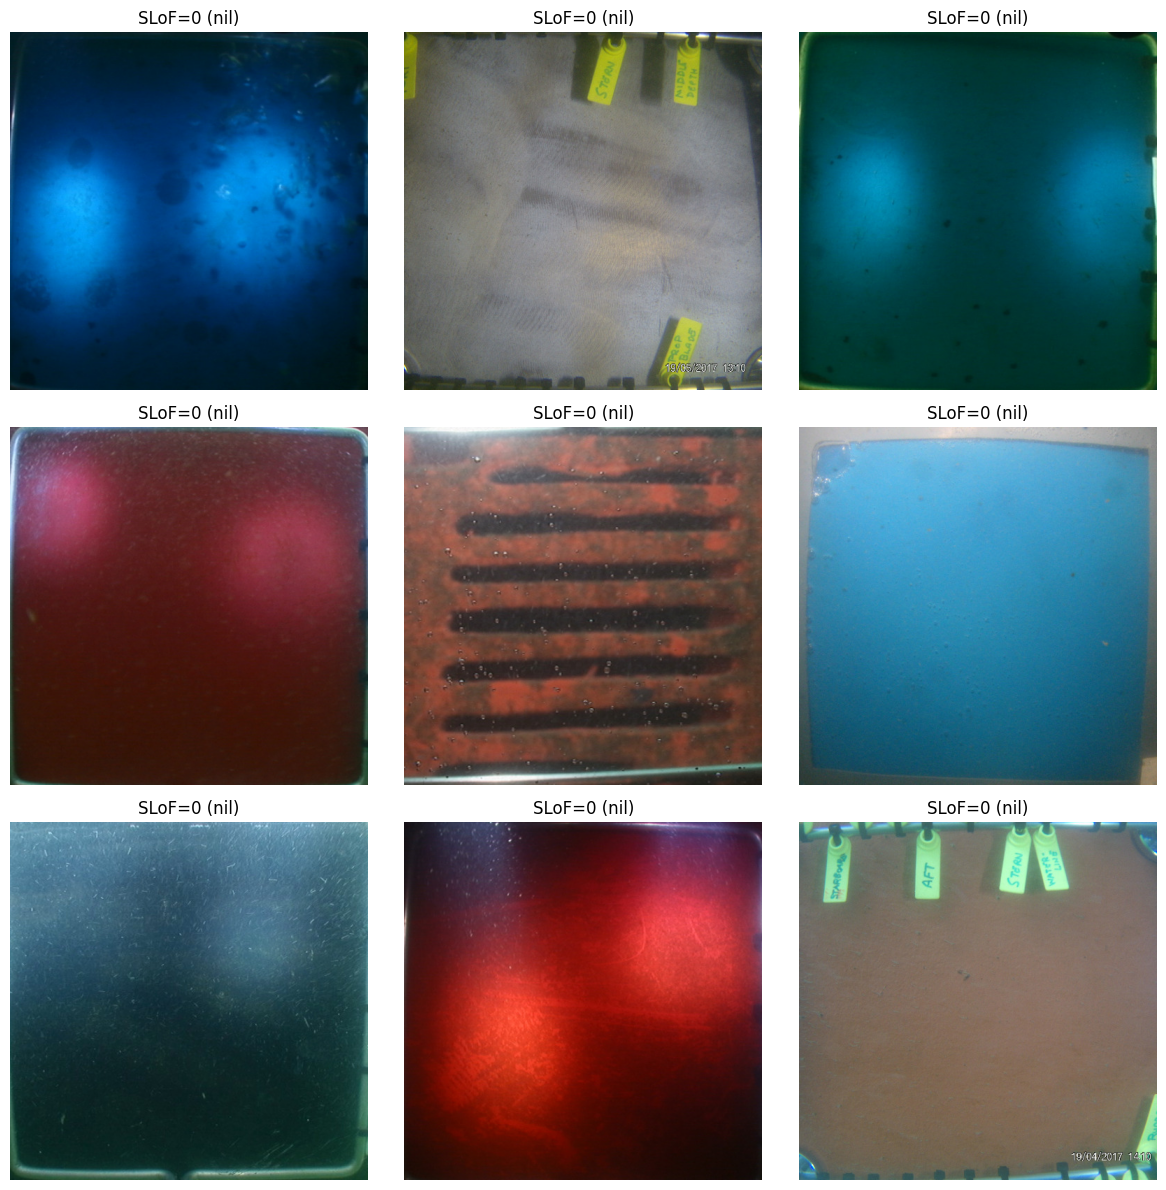

In [9]:
def show_examples(df_subset, n=9):
    rows = df_subset.sample(n=min(n, len(df_subset)), random_state=SEED)
    cols = int(np.ceil(np.sqrt(n)))
    rws  = int(np.ceil(n / cols))

    plt.figure(figsize=(4*cols, 4*rws))
    for i, (_, row) in enumerate(rows.iterrows(), start=1):
        path = os.path.join(IMAGES_ROOT, row["image.name"])
        img = Image.open(path).convert("RGB")
        plt.subplot(rws, cols, i)
        plt.imshow(img)
        plt.title(f"SLoF={row['SLoF']} ({LABEL_MAP[int(row['SLoF'])]})")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_examples(train_df, n=9)

In [10]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)

In [11]:
import random
import numpy as np
import torch
from PIL import Image, ImageEnhance

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def center_crop(img, crop_size):
    w, h = img.size
    left = (w - crop_size) // 2
    top  = (h - crop_size) // 2
    return img.crop((left, top, left + crop_size, top + crop_size))

def random_crop(img, crop_size):
    w, h = img.size
    if w <= crop_size or h <= crop_size:
        return img.resize((crop_size, crop_size), resample=Image.BILINEAR)
    left = random.randint(0, w - crop_size)
    top  = random.randint(0, h - crop_size)
    return img.crop((left, top, left + crop_size, top + crop_size))

def to_tensor(img):
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.transpose(arr, (2, 0, 1))  # HWC -> CHW
    return torch.from_numpy(arr)

def normalize(x, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean, dtype=x.dtype).view(3, 1, 1)
    std  = torch.tensor(std,  dtype=x.dtype).view(3, 1, 1)
    return (x - mean) / std

class TrainTransform:
    def __init__(self, img_size=224):
        self.img_size = img_size
        self.resize_size = int(img_size * 1.15)

    def __call__(self, img: Image.Image):
        # resize -> random crop
        img = img.resize((self.resize_size, self.resize_size), resample=Image.BILINEAR)
        img = random_crop(img, self.img_size)

        # flip
        if random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)

        # rotate
        img = img.rotate(random.uniform(-8, 8), resample=Image.BILINEAR)

        # brightness/contrast jitter
        if random.random() < 0.8:
            img = ImageEnhance.Brightness(img).enhance(random.uniform(0.75, 1.25))
            img = ImageEnhance.Contrast(img).enhance(random.uniform(0.75, 1.25))

        x = normalize(to_tensor(img))
        return x

class ValTransform:
    def __init__(self, img_size=224):
        self.img_size = img_size
        self.resize_size = int(img_size * 1.15)

    def __call__(self, img: Image.Image):
        img = img.resize((self.resize_size, self.resize_size), resample=Image.BILINEAR)
        img = center_crop(img, self.img_size)
        x = normalize(to_tensor(img))
        return x

train_tfms = TrainTransform(IMG_SIZE)
val_tfms   = ValTransform(IMG_SIZE)

In [12]:
import os
from torch.utils.data import Dataset
from PIL import Image

class BiofoulingDataset(Dataset):
    def __init__(self, df, images_root, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_root = images_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_root, row["image.name"])
        y = int(row["SLoF"])

        img = Image.open(img_path).convert("RGB")
        x = self.transform(img) if self.transform else img
        return x, y

train_ds = BiofoulingDataset(train_df, IMAGES_ROOT, transform=train_tfms)
val_ds   = BiofoulingDataset(val_df,   IMAGES_ROOT, transform=val_tfms)

x0, y0 = train_ds[0]
print("Sample:", x0.shape, x0.dtype, "label:", y0)

Sample: torch.Size([3, 224, 224]) torch.float32 label: 0


In [13]:
from torch.utils.data import DataLoader

NUM_WORKERS = 2  # you can try 4 if stable

train_loader = DataLoader(
    train_ds, batch_size=BATCH_TRAIN, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_VAL, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS > 0)
)

In [14]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [15]:
import numpy as np
import torch
import torch.nn as nn

train_labels = train_df["SLoF"].to_numpy()
counts = np.bincount(train_labels, minlength=3)

w = 1.0 / np.sqrt(counts + 1e-9)
w = w / w.mean()

class_weights = torch.tensor(w, dtype=torch.float32, device=device)
print("Train counts:", counts, "->", [LABEL_MAP[i] for i in range(3)])
print("Loss weights:", class_weights.detach().cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights)

Train counts: [7328 1503  591] -> ['nil', 'medium', 'heavy']
Loss weights: [0.445809  0.9843784 1.5698127]


In [ ]:
import torch
import torch.nn as nn

# Targeted emphasis on medium
class_weights = torch.tensor([0.8, 2.5, 1.2], dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Using class weights:", class_weights.detach().cpu().numpy())

In [ ]:
import torch
import torch.nn as nn

# Targeted emphasis on balanced
class_weights = torch.tensor([0.9, 1.6, 1.8], dtype=torch.float32, device=device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
print("Using class weights:", class_weights.detach().cpu().numpy())

In [16]:
import torch
import torch.nn as nn

# Targeted emphasis on medium updated
class_weights = torch.tensor([0.9, 2.2, 1.8], dtype=torch.float32, device=device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
print("Using class weights:", class_weights.detach().cpu().numpy())

Using class weights: [0.9 2.2 1.8]


In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_metrics(model, loader, device):
    model.eval()
    all_preds, all_tgts = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_tgts.append(y.cpu())

    preds = torch.cat(all_preds).numpy()
    tgts  = torch.cat(all_tgts).numpy()

    acc = float((preds == tgts).mean())

    cm = np.zeros((3, 3), dtype=int)
    for t, p in zip(tgts, preds):
        cm[int(t), int(p)] += 1

    f1s = []
    for c in [0, 1, 2]:
        tp = np.sum((preds == c) & (tgts == c))
        fp = np.sum((preds == c) & (tgts != c))
        fn = np.sum((preds != c) & (tgts == c))
        precision = tp / (tp + fp + 1e-9)
        recall    = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        f1s.append(f1)

    macro_f1 = float(np.mean(f1s))
    return acc, macro_f1, cm

@torch.no_grad()
def evaluate_metrics_with_recall(model, loader, device):
    acc, macro_f1, cm = evaluate_metrics(model, loader, device)
    recalls = []
    for i in range(3):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        recalls.append(float(tp / (tp + fn + 1e-9)))
    return acc, macro_f1, cm, recalls

def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

labels = [LABEL_MAP[0], LABEL_MAP[1], LABEL_MAP[2]]

In [18]:
import torch
import torch.nn as nn

def conv3x3(in_ch, out_ch, stride=1):
    return nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1   = nn.BatchNorm2d(planes)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes, 1)
        self.bn2   = nn.BatchNorm2d(planes)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out = self.relu(out + identity)
        return out

class ResNet(nn.Module):
    def __init__(self, layers, num_classes=3):
        super().__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.relu  = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64,  layers[0], stride=1)
        self.layer2 = self._make_layer(128, layers[1], stride=2)
        self.layer3 = self._make_layer(256, layers[2], stride=2)
        self.layer4 = self._make_layer(512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, planes, blocks, stride):
        downsample = None
        if stride != 1 or self.inplanes != planes:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )

        layers = [BasicBlock(self.inplanes, planes, stride=stride, downsample=downsample)]
        self.inplanes = planes
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

def resnet18(num_classes=3):
    return ResNet([2, 2, 2, 2], num_classes=num_classes)

model = resnet18(num_classes=3).to(device)
print("Model on:", next(model.parameters()).device)

Model on: cuda:0


In [ ]:
# import torch
# from torch.cuda.amp import autocast, GradScaler

# # Create/reset history before training
# history = {"epoch": [], "train_loss": [], "val_acc": [], "val_macro_f1": []}

# torch.backends.cudnn.benchmark = True  # speed (OK when input sizes fixed)

# def train_one_epoch(model, loader, optimizer, scaler, device):
#     model.train()
#     total_loss, n = 0.0, 0
#     for x, y in loader:
#         x = x.to(device, non_blocking=True)
#         y = y.to(device, non_blocking=True)

#         optimizer.zero_grad(set_to_none=True)
#         with autocast(enabled=(device.type == "cuda")):
#             logits = model(x)
#             loss = criterion(logits, y)

#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()

#         total_loss += loss.item() * x.size(0)
#         n += x.size(0)
#     return total_loss / max(n, 1)

# def train_epochs(model, epochs=10, lr=1e-3):
#     optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
#     scaler = GradScaler(enabled=(device.type == "cuda"))

#     best_macro_f1 = -1.0
#     best_state = None

#     for ep in range(1, epochs + 1):
#         tr_loss = train_one_epoch(model, train_loader, optimizer, scaler, device)
#         acc, macro_f1, cm = evaluate_metrics(model, val_loader, device)

#         print(f"[{ep:02d}/{epochs}] train_loss={tr_loss:.4f} val_acc={acc:.4f} val_macroF1={macro_f1:.4f}")
#         plot_confusion_matrix(cm, labels)

#         if macro_f1 > best_macro_f1:
#             best_macro_f1 = macro_f1
#             best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

#     model.load_state_dict(best_state)
#     return best_macro_f1



In [19]:
import torch
from torch.cuda.amp import autocast, GradScaler

# Create/reset history before training
history = {
    "epoch": [],
    "train_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
    "recall_nil": [],
    "recall_medium": [],
    "recall_heavy": [],
}

torch.backends.cudnn.benchmark = True  # faster on fixed-size inputs

def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()
    total_loss, n = 0.0, 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=(device.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

    return total_loss / max(n, 1)

def train_epochs(model, epochs=10, lr=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = GradScaler(enabled=(device.type == "cuda"))

    best_macro_f1 = -1.0
    best_state = None

    for ep in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, scaler, device)

        # ---- validation metrics + per-class recall ----
        acc, macro_f1, cm, recalls = evaluate_metrics_with_recall(model, val_loader, device)

        # ---- logging ----
        history["epoch"].append(ep)
        history["train_loss"].append(tr_loss)
        history["val_acc"].append(acc)
        history["val_macro_f1"].append(macro_f1)
        history["recall_nil"].append(recalls[0])
        history["recall_medium"].append(recalls[1])
        history["recall_heavy"].append(recalls[2])

        # ---- reporting ----
        print(
            f"[{ep:02d}/{epochs}] "
            f"train_loss={tr_loss:.4f} val_acc={acc:.4f} val_macroF1={macro_f1:.4f} | "
            f"recall(nil,med,heavy)=({recalls[0]:.3f},{recalls[1]:.3f},{recalls[2]:.3f})"
        )
        plot_confusion_matrix(cm, labels)

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return best_macro_f1


/tmp/ipykernel_29546/947106687.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[01/12] train_loss=0.8600 val_acc=0.5874 val_macroF1=0.2467


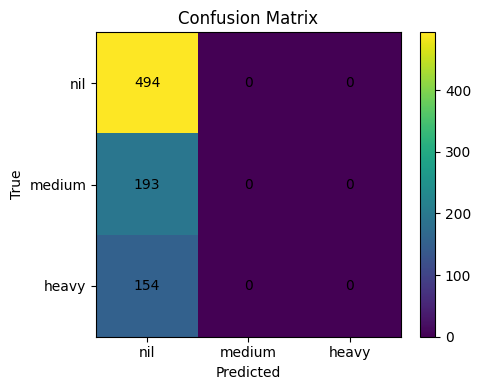

/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[02/12] train_loss=0.7944 val_acc=0.6397 val_macroF1=0.4481


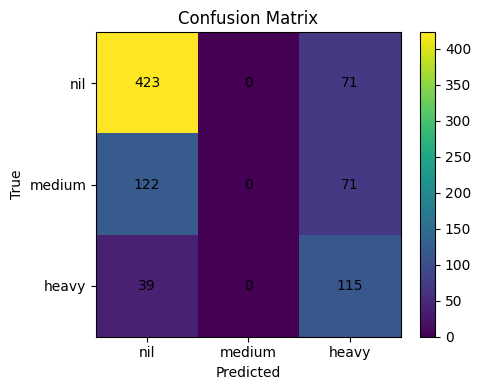

/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[03/12] train_loss=0.7710 val_acc=0.6254 val_macroF1=0.4343


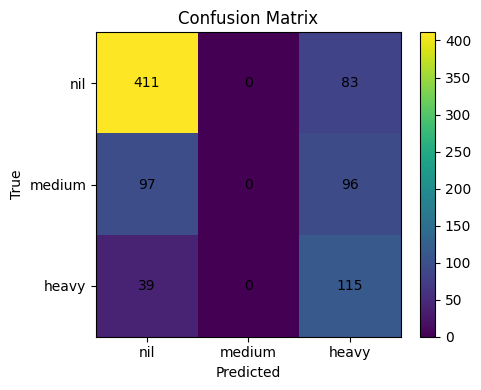

/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[04/12] train_loss=0.7638 val_acc=0.6492 val_macroF1=0.4417


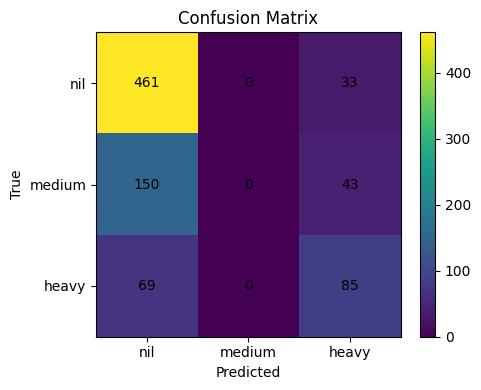

/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[05/12] train_loss=0.7487 val_acc=0.6457 val_macroF1=0.4441


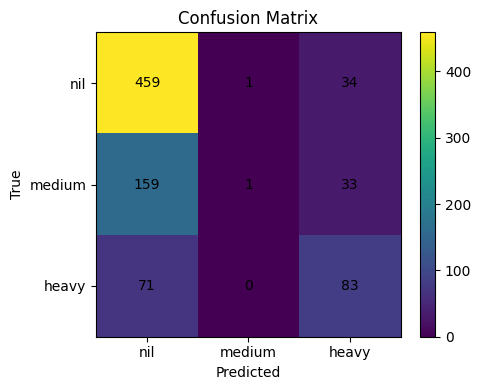

/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[06/12] train_loss=0.7373 val_acc=0.6635 val_macroF1=0.4733


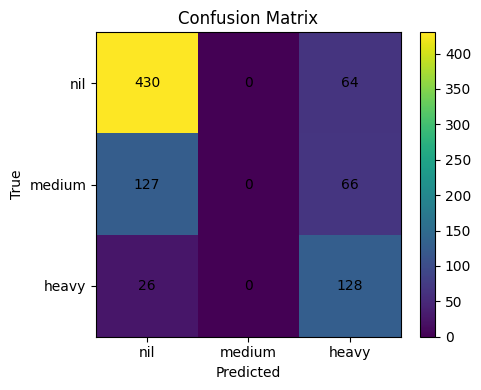

/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[07/12] train_loss=0.7363 val_acc=0.6290 val_macroF1=0.4869


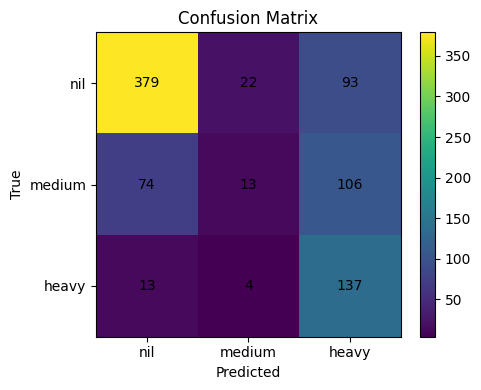

/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[08/12] train_loss=0.7276 val_acc=0.6623 val_macroF1=0.4811


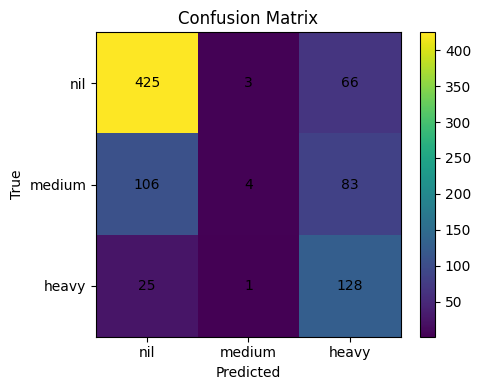

/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[09/12] train_loss=0.7274 val_acc=0.6647 val_macroF1=0.5177


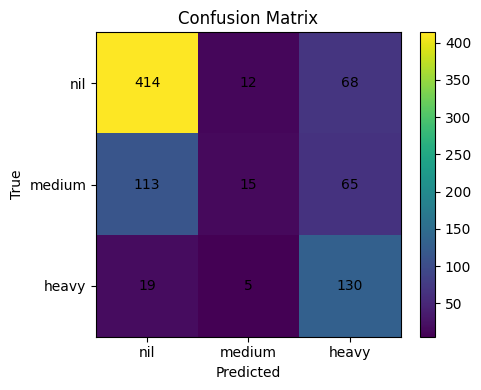

/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[10/12] train_loss=0.7208 val_acc=0.6278 val_macroF1=0.4319


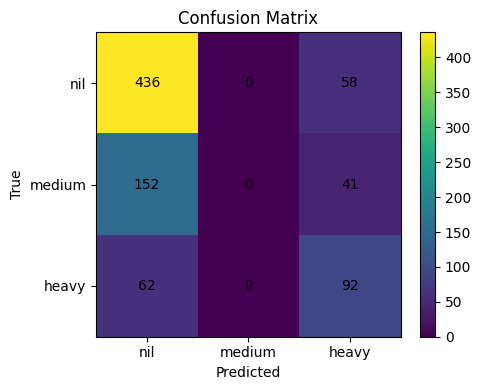

/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[11/12] train_loss=0.7178 val_acc=0.5826 val_macroF1=0.2521


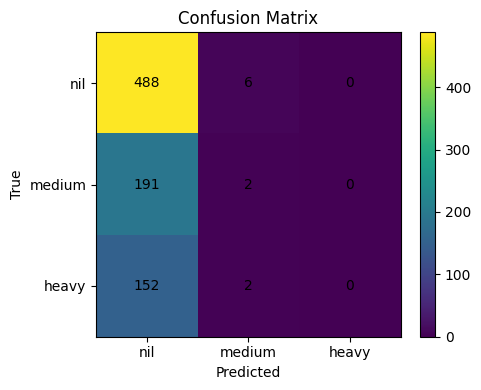

/tmp/ipykernel_29546/947106687.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[12/12] train_loss=0.7097 val_acc=0.6599 val_macroF1=0.5483


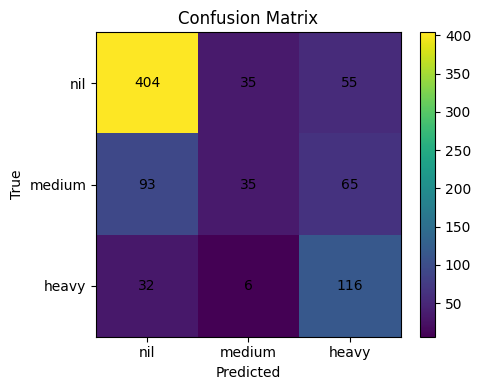

Best validation macro-F1: 0.5483095546338557


In [26]:
best_f1 = train_epochs(model, epochs=12, lr=1e-3)
print("Best validation macro-F1:", best_f1)

/tmp/ipykernel_58460/2292360735.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[01/12] train_loss=0.9050 val_acc=0.5874 val_macroF1=0.2469 | recall(nil,med,heavy)=(1.000,0.000,0.000)


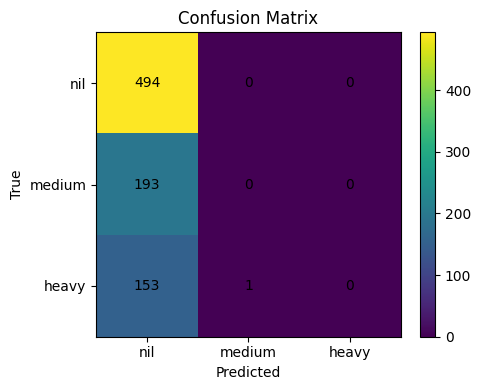

/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[02/12] train_loss=0.8363 val_acc=0.5779 val_macroF1=0.4039 | recall(nil,med,heavy)=(0.704,0.715,0.000)


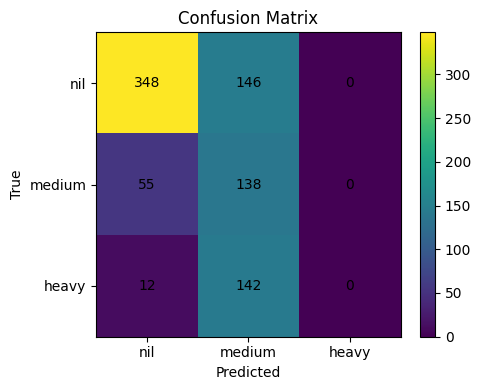

/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[03/12] train_loss=0.8180 val_acc=0.6433 val_macroF1=0.4573 | recall(nil,med,heavy)=(0.842,0.010,0.799)


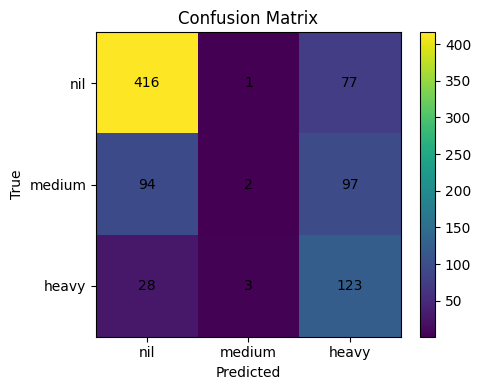

/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[04/12] train_loss=0.8000 val_acc=0.5993 val_macroF1=0.4933 | recall(nil,med,heavy)=(0.773,0.264,0.461)


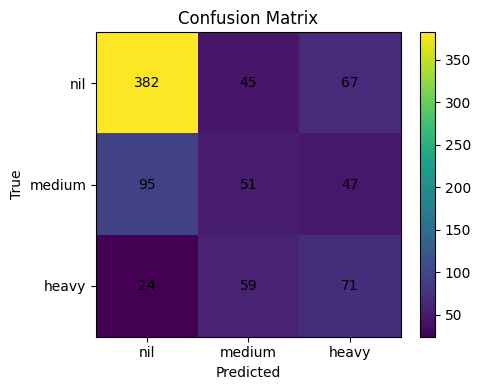

/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[05/12] train_loss=0.7929 val_acc=0.6302 val_macroF1=0.4728 | recall(nil,med,heavy)=(0.891,0.306,0.201)


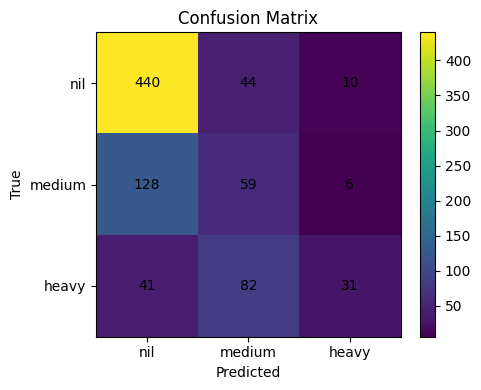

/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[06/12] train_loss=0.7833 val_acc=0.6207 val_macroF1=0.4896 | recall(nil,med,heavy)=(0.749,0.088,0.877)


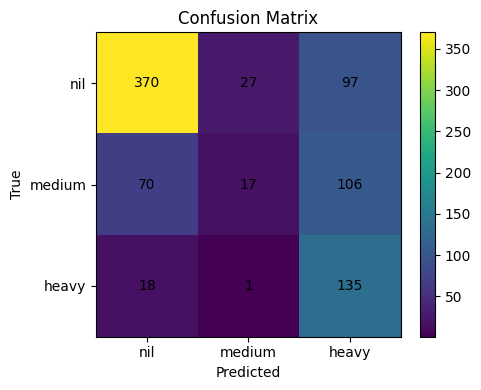

/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[07/12] train_loss=0.7776 val_acc=0.5815 val_macroF1=0.5367 | recall(nil,med,heavy)=(0.613,0.389,0.721)


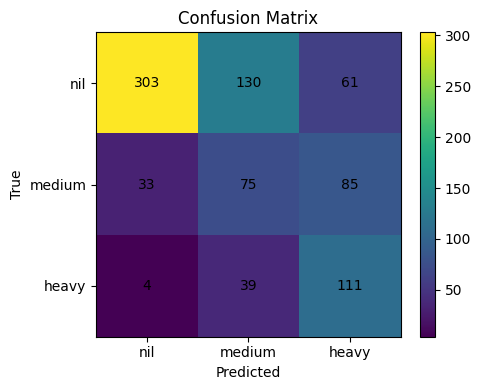

/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[08/12] train_loss=0.7692 val_acc=0.6231 val_macroF1=0.5228 | recall(nil,med,heavy)=(0.773,0.518,0.273)


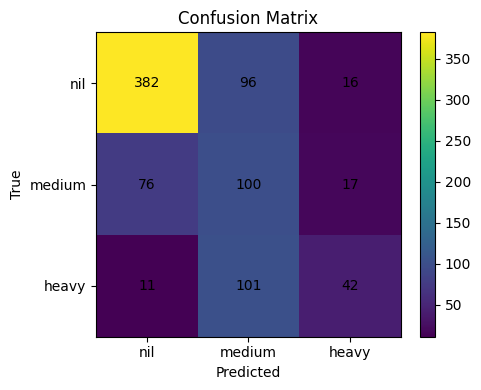

/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[09/12] train_loss=0.7669 val_acc=0.6338 val_macroF1=0.5493 | recall(nil,med,heavy)=(0.719,0.233,0.864)


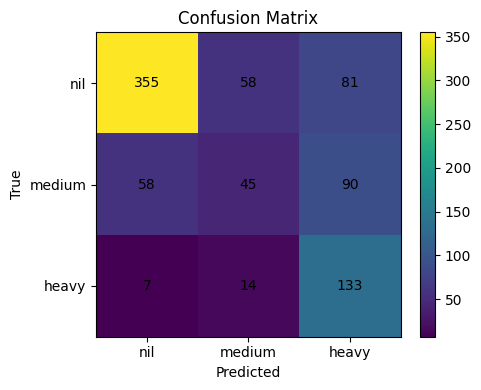

/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[10/12] train_loss=0.7552 val_acc=0.6243 val_macroF1=0.5268 | recall(nil,med,heavy)=(0.785,0.301,0.513)


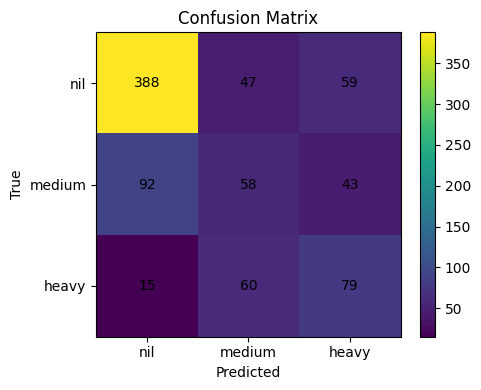

/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[11/12] train_loss=0.7490 val_acc=0.5850 val_macroF1=0.3905 | recall(nil,med,heavy)=(0.798,0.503,0.006)


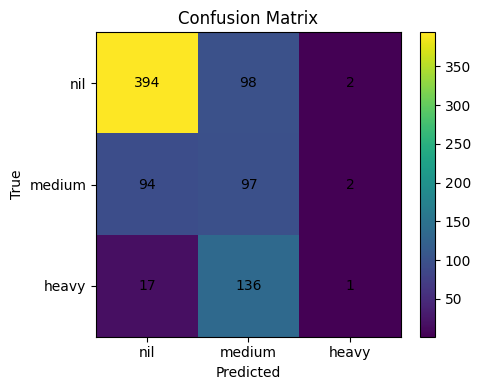

/tmp/ipykernel_58460/2292360735.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


[12/12] train_loss=0.7490 val_acc=0.6147 val_macroF1=0.5623 | recall(nil,med,heavy)=(0.668,0.409,0.701)


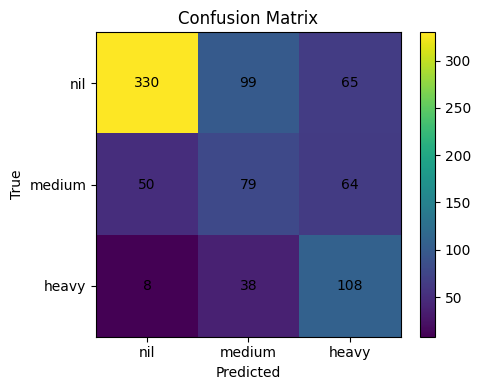

Best validation macro-F1: 0.5623456847438842


In [20]:
# New training according to medium updated weights
best_f1 = train_epochs(model, epochs=12, lr=1e-3)
print("Best validation macro-F1:", best_f1)

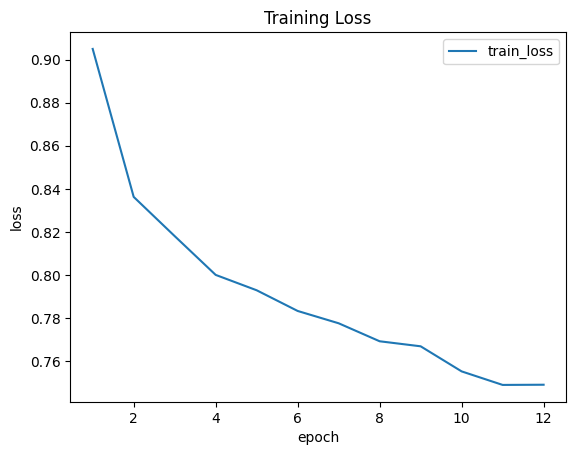

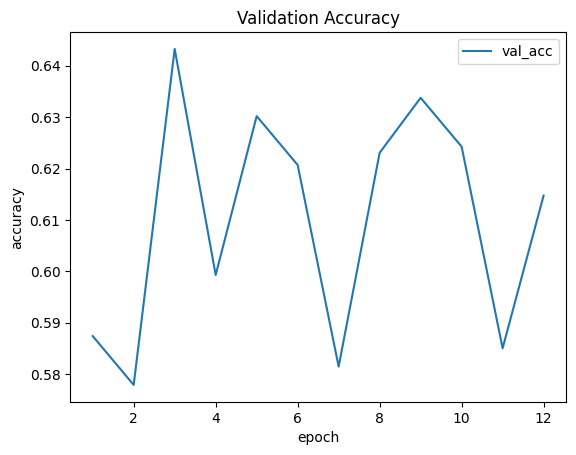

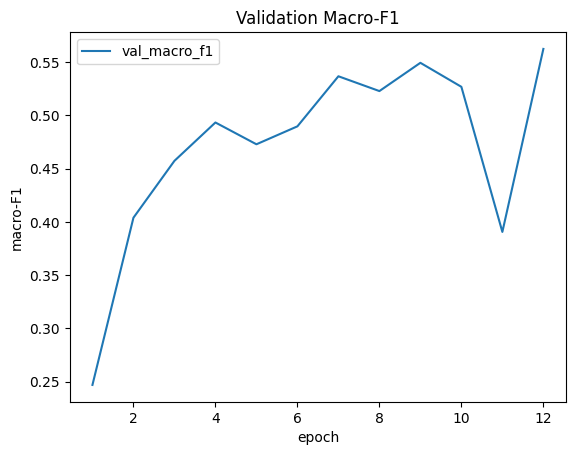

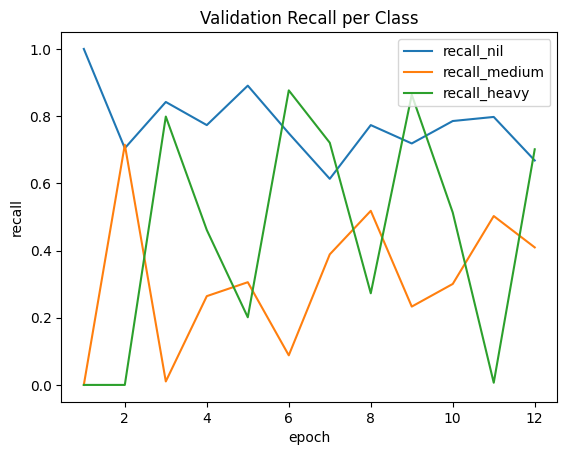

,epoch,train_loss,val_acc,val_macro_f1,recall_nil,recall_medium,recall_heavy
7,8,0.769220,0.623068,0.522777,0.773279,0.518135,0.272727
8,9,0.766887,0.633769,0.549305,0.718623,0.233161,0.863636
9,10,0.755238,0.624257,0.526765,0.785425,0.300518,0.512987
10,11,0.748954,0.585018,0.390532,0.797571,0.502591,0.006494
11,12,0.749043,0.614744,0.562346,0.668016,0.409326,0.701299


In [24]:
import matplotlib.pyplot as plt
import pandas as pd

hist_df = pd.DataFrame(history)

# 1) Loss
plt.figure()
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training Loss")
plt.legend()
plt.show()

# 2) Validation accuracy
plt.figure()
plt.plot(hist_df["epoch"], hist_df["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.show()

# 3) Validation macro-F1
plt.figure()
plt.plot(hist_df["epoch"], hist_df["val_macro_f1"], label="val_macro_f1")
plt.xlabel("epoch")
plt.ylabel("macro-F1")
plt.title("Validation Macro-F1")
plt.legend()
plt.show()

# 4) Validation Recall per Class
plt.figure()
plt.plot(hist_df["epoch"], hist_df["recall_nil"], label="recall_nil")
plt.plot(hist_df["epoch"], hist_df["recall_medium"], label="recall_medium")
plt.plot(hist_df["epoch"], hist_df["recall_heavy"], label="recall_heavy")
plt.xlabel("epoch")
plt.ylabel("recall")
plt.title("Validation Recall per Class")
plt.legend()
plt.show()

hist_df.tail()

In [23]:
def per_class_metrics(cm, labels):
    for i, name in enumerate(labels):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        precision = tp / (tp + fp + 1e-9)
        recall    = tp / (tp + fn + 1e-9)
        f1        = 2 * precision * recall / (precision + recall + 1e-9)
        support   = cm[i, :].sum()
        print(f"{name:>6}: precision={precision:.3f} recall={recall:.3f} f1={f1:.3f} support={support}")

acc, macro_f1, cm = evaluate_metrics(model, val_loader, device)
print(f"Final: val_acc={acc:.4f} val_macroF1={macro_f1:.4f}")
per_class_metrics(cm, labels)

Final: val_acc=0.6147 val_macroF1=0.5623
   nil: precision=0.851 recall=0.668 f1=0.748 support=494
medium: precision=0.366 recall=0.409 f1=0.386 support=193
 heavy: precision=0.456 recall=0.701 f1=0.552 support=154


Major step forward: the validation macro-F1 moved from “collapsed model” territory to a workable baseline.

What the current results mean

Nil is learned well: F1 ≈ 0.80 (precision 0.796, recall 0.804).

Heavy is learned reasonably well: F1 ≈ 0.57 (recall 0.903, but precision 0.417 → many false positives).

Medium is essentially not being predicted: recall 0.016 (only ~1–3 images out of 193 are being called “medium”).

So the model is behaving like a two-class detector (“nil vs heavy”), and it is routing many true medium images into either nil or heavy. Your accuracy (0.6409) is largely coming from the majority class (nil) plus strong heavy recall.

The next work is therefore very focused: recover medium without destroying nil/heavy.

In [20]:
import numpy as np
import torch

acc, macro_f1, cm = evaluate_metrics(model, val_loader, device)
print("Confusion matrix (rows=true, cols=pred):\n", cm)
# rows: [nil, medium, heavy]; cols: [nil, medium, heavy]

@torch.no_grad()
def pred_distribution(model, loader, device):
    model.eval()
    preds_all = []
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        preds_all.append(model(x).argmax(dim=1).cpu().numpy())
    preds_all = np.concatenate(preds_all)
    counts = np.bincount(preds_all, minlength=3)
    return counts, counts / counts.sum()

counts, frac = pred_distribution(model, val_loader, device)
print("Pred counts:", counts)
print("Pred fractions:", frac, "labels:", [LABEL_MAP[i] for i in range(3)])

Confusion matrix (rows=true, cols=pred):
 [[433  61   0]
 [110  83   0]
 [ 36 118   0]]
Pred counts: [579 262   0]
Pred fractions: [0.68846611 0.31153389 0.        ] labels: ['nil', 'medium', 'heavy']


The current weighting scheme favors heavy relative to nil; that can make the model “play it safe” by calling borderline cases heavy. We need to raise the penalty for misclassifying medium (especially medium→heavy) and often slightly reduce heavy’s dominance.

Replace the loss weights with a manual, targeted set (start here, then tune):

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha  # tensor shape [C] or None
        self.gamma = gamma

    def forward(self, logits, target):
        logp = F.log_softmax(logits, dim=1)
        p = torch.exp(logp)
        pt = p.gather(1, target.view(-1, 1)).squeeze(1)          # p(correct class)
        logpt = logp.gather(1, target.view(-1, 1)).squeeze(1)

        if self.alpha is not None:
            at = self.alpha.gather(0, target)
            loss = -at * ((1 - pt) ** self.gamma) * logpt
        else:
            loss = -((1 - pt) ** self.gamma) * logpt

        return loss.mean()

alpha = torch.tensor([0.8, 2.5, 1.2], dtype=torch.float32, device=device)
criterion = FocalLoss(alpha=alpha, gamma=2.0)